# 1.04 — Visualization & Machine Learning Libraries

In this lab we will use:
- **Matplotlib**: the base plotting library in Python
- **Seaborn**: statistical plots built on top of Matplotlib (nicer defaults)
- **scikit-learn**: classic machine learning toolkit (models, preprocessing, evaluation)

Dataset used (same as Lab 1.03):
- `data/data_lab_1.03.csv`

In [1]:
# (Optional) Install libraries if needed
# If you already installed them in your environment, you can skip this cell.
! pip install -q pandas numpy matplotlib seaborn scikit-learn

In [1]:
# Imports + load dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data_frame = pd.read_csv('data/data_lab_1.03.csv')
data_frame.head()

,gender,group,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### Quick overview

In [2]:

print('Shape:', data_frame.shape)
display(data_frame.info())
data_frame.describe()

Shape: (1000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   group                        1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


None

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


## Matplotlib (basic plots)
Matplotlib is the foundation. Seaborn uses it under the hood.

Histogram of math_score

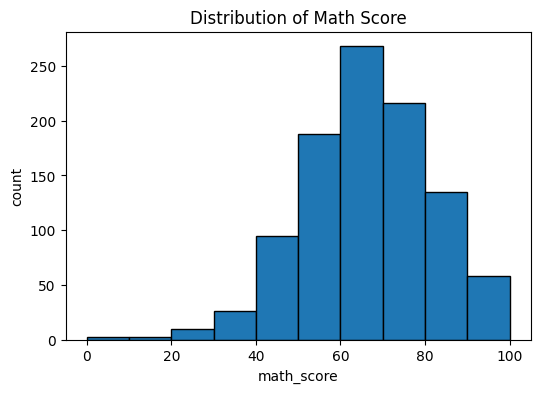

In [3]:
plt.figure(figsize=(6, 4))
plt.hist(data_frame['math_score'], bins=10, edgecolor='black')
plt.title('Distribution of Math Score')
plt.xlabel('math_score')
plt.ylabel('count')
plt.show()

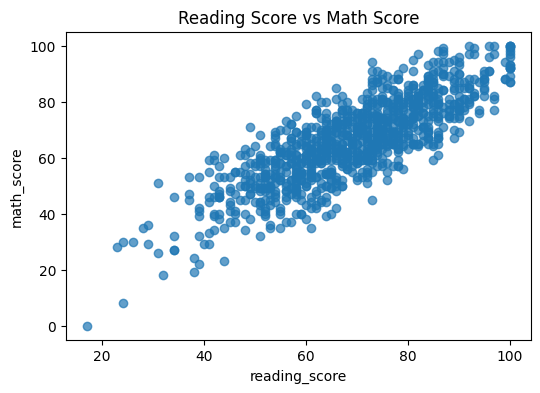

In [4]:
# Scatter plot: reading_score vs math_score
plt.figure(figsize=(6, 4))
plt.scatter(data_frame['reading_score'], data_frame['math_score'], alpha=0.7)
plt.title('Reading Score vs Math Score')
plt.xlabel('reading_score')
plt.ylabel('math_score')
plt.show()

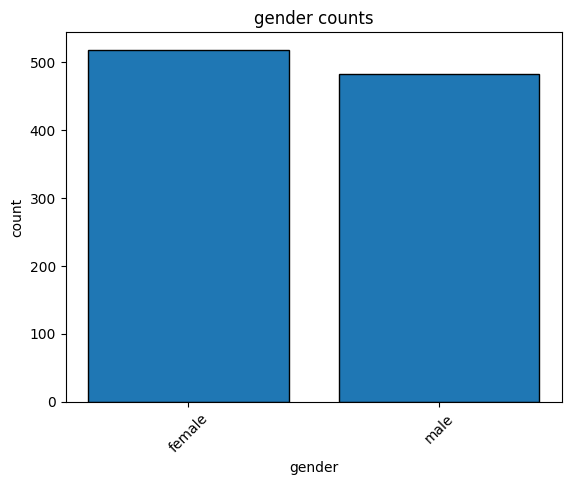

In [5]:

# categorical_cols = ['gender', 'race_ethnicity', 'parental_level_of_education']

counts = data_frame['gender'].value_counts()
plt.bar(counts.index.astype(str), counts.values, edgecolor='black')
plt.title('gender counts')
plt.xlabel('gender')
plt.ylabel('count')
plt.tick_params(axis='x', rotation=45)

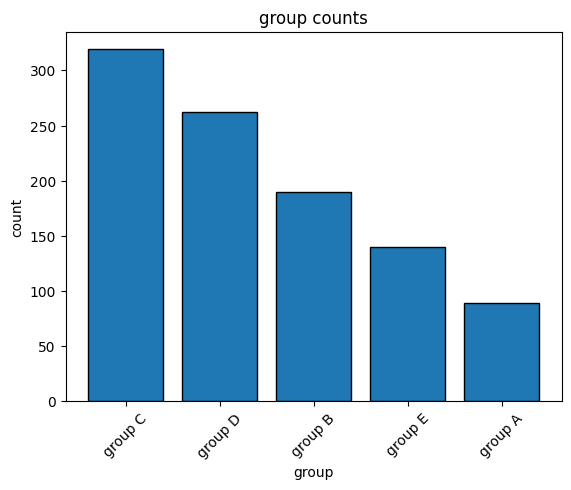

In [6]:
counts = data_frame['group'].value_counts()
plt.bar(counts.index.astype(str), counts.values, edgecolor='black')
plt.title('group counts')
plt.xlabel('group')
plt.ylabel('count')
plt.tick_params(axis='x', rotation=45)

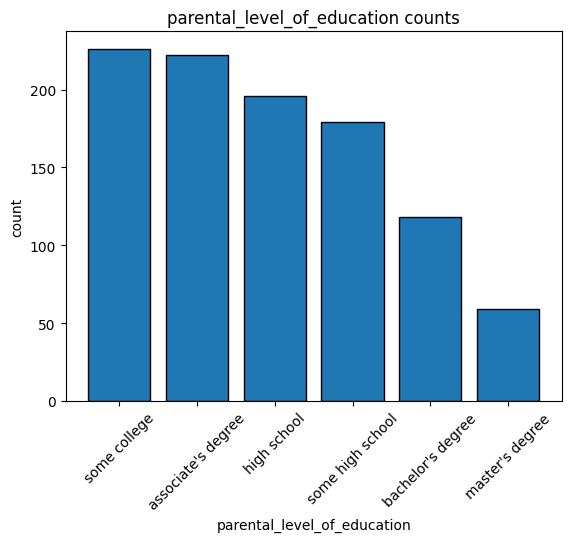

In [7]:
counts = data_frame['parental_level_of_education'].value_counts()
plt.bar(counts.index.astype(str), counts.values, edgecolor='black')
plt.title('parental_level_of_education counts')
plt.xlabel('parental_level_of_education')
plt.ylabel('count')
plt.tick_params(axis='x', rotation=45)

## Seaborn (statistical plots)
Seaborn makes it easy to create common plots with better defaults.

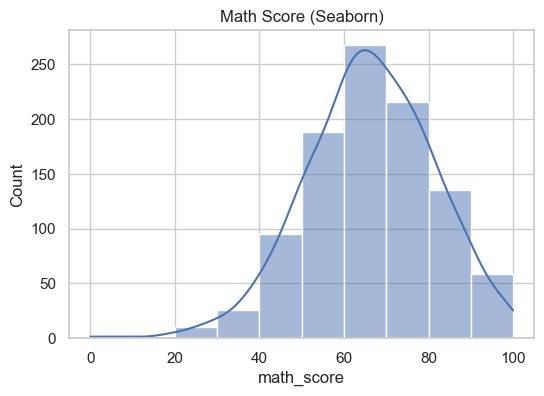

In [8]:
sns.set_theme(style='whitegrid')

# Histogram with KDE
plt.figure(figsize=(6, 4))
sns.histplot(data=data_frame, x='math_score', bins=10, kde=True)
plt.title('Math Score (Seaborn)')
plt.show()

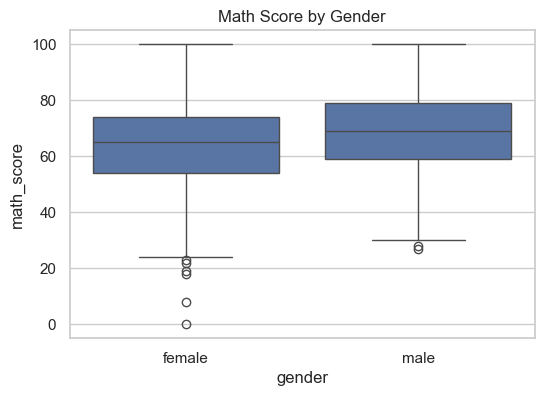

In [9]:
# Boxplot: math_score by gender
plt.figure(figsize=(6, 4))
sns.boxplot(data=data_frame, x='gender', y='math_score')
plt.title('Math Score by Gender')
plt.show()

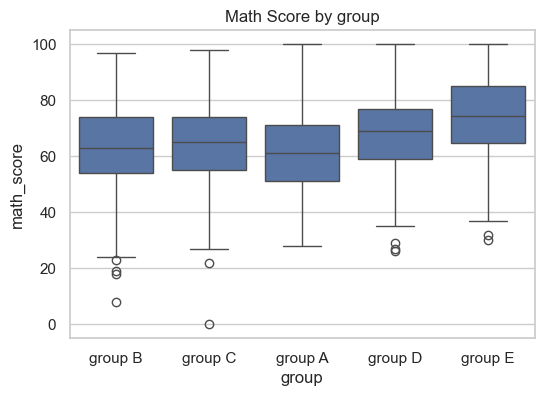

In [10]:
# Boxplot: math_score by gender
plt.figure(figsize=(6, 4))
sns.boxplot(data=data_frame, x='group', y='math_score')
plt.title('Math Score by group')
plt.show()

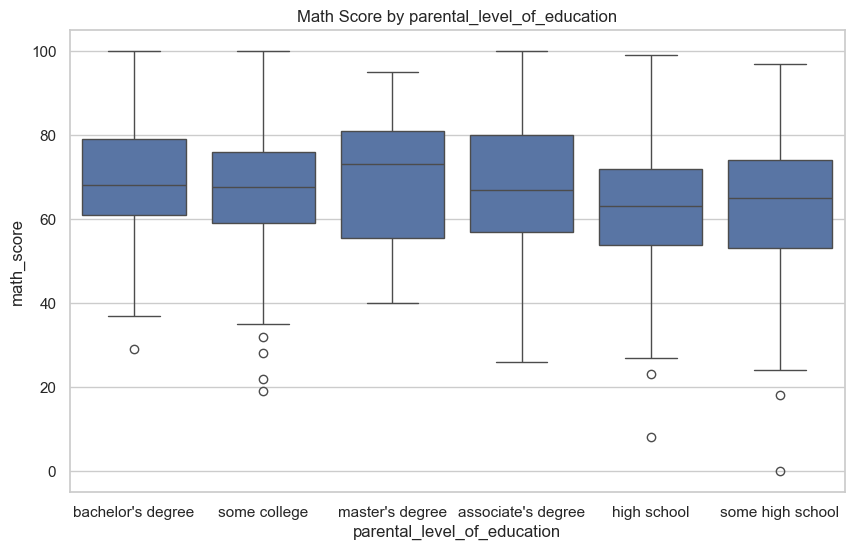

In [11]:
# Boxplot: math_score by gender
plt.figure(figsize=(10, 6))
sns.boxplot(data=data_frame, x='parental_level_of_education', y='math_score')
plt.title('Math Score by parental_level_of_education')
plt.show()

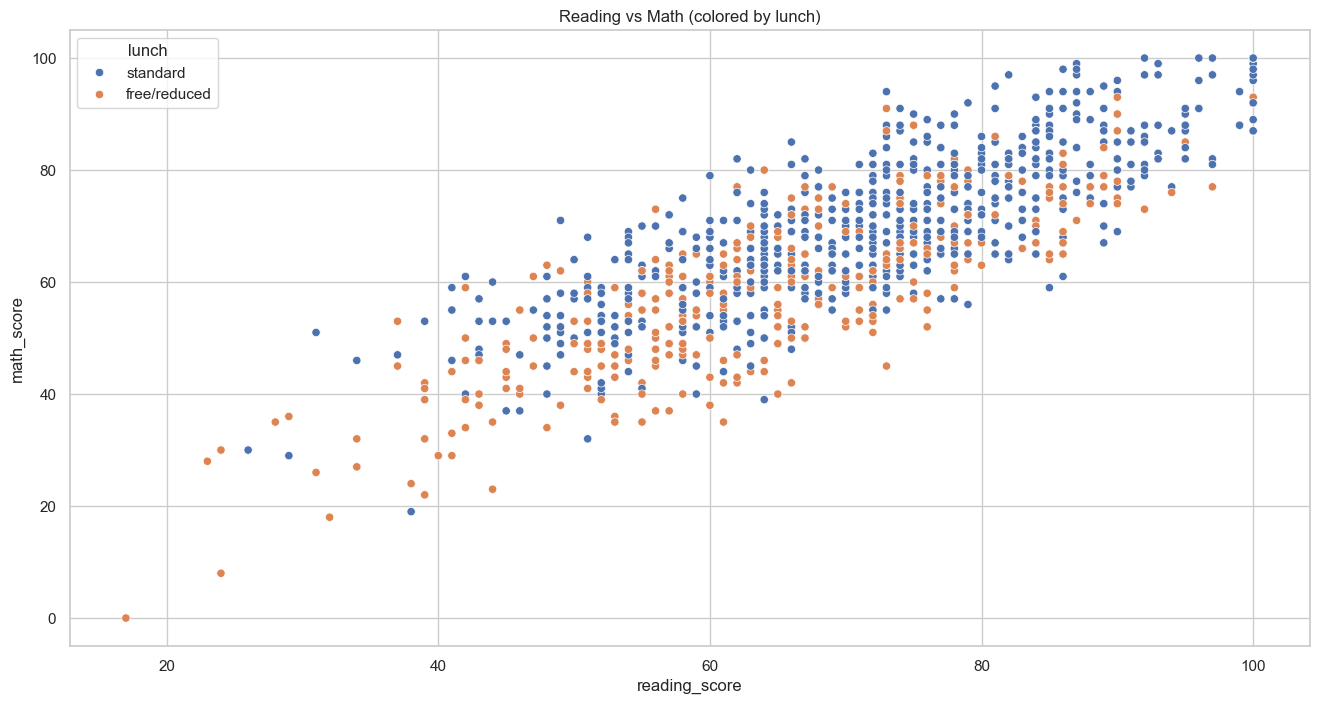

In [12]:
# Relationship plot: reading_score vs math_score, colored by lunch
plt.figure(figsize=(16, 8))
sns.scatterplot(data=data_frame, x='reading_score', y='math_score', hue='lunch')
plt.title('Reading vs Math (colored by lunch)')
plt.show()

## scikit-learn (a first ML model)
We will build a very small **regression** model to predict `math_score` using:
- `reading_score`
- `writing_score`

Why these features? They are numeric already, so we don’t need encoding yet (we’ll do categorical encoding later in the course).

In [13]:
from sklearn.model_selection import train_test_split

# Features (X) and target (y)
X = data_frame[['reading_score', 'writing_score']]
y = data_frame['math_score']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
 )

In [14]:
from sklearn.linear_model import LinearRegression
# Train a simple model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [15]:
# Predict and evaluate
y_pred = model.predict(X_test)

In [16]:
print("y_pred (first 8):", [float(round(val, 2)) for val in y_pred[:8]])
print("y_test (first 8):", y_test.values[:8].tolist())

y_pred (first 8): [80.19, 65.68, 69.44, 72.02, 76.83, 72.22, 65.27, 59.82]
y_test (first 8): [91, 53, 80, 74, 84, 81, 69, 54]


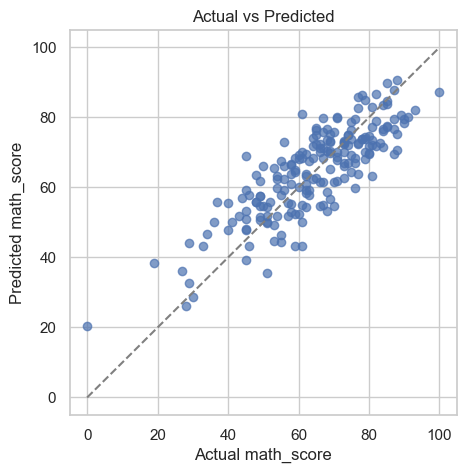

In [17]:
# Visualize predictions vs actual (perfect model would lie on the diagonal)
plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('Actual math_score')
plt.ylabel('Predicted math_score')
plt.title('Actual vs Predicted')

min_v = min(y_test.min(), y_pred.min())
max_v = max(y_test.max(), y_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], '--', color='gray')
plt.show()

## Other useful libraries (good to know)
These are commonly used in ML projects:
- **NumPy**: numerical arrays (foundation for many libraries)
- **pandas**: tabular data manipulation
- **SciPy**: scientific computing (statistics, optimization)
- **Plotly**: interactive plots (nice for dashboards and exploration)
- **Statsmodels**: statistical models + detailed summaries (useful in data analysis)

We will focus mainly on Matplotlib, Seaborn, and scikit-learn in this course.